In [2]:
from pathlib import Path
import pandas as pd

file_path = Path("all_classified_planets_Harshitha.csv")
TOIs = pd.read_csv(file_path)

print(f"Loaded {file_path} with shape: {TOIs.shape}")
TOIs.head()

Loaded all_classified_planets_Harshitha.csv with shape: (736, 71)


,toi,tid,tfopwg_disp,rastr,ra,decstr,dec,st_pmra,st_pmraerr1,st_pmraerr2,...,st_raderr2,st_radlim,toi_created,rowupdate,cdpp,pl_perturbed,sector_array,FPP,NFPP,classification
0,6903.01,9216075,APC,23h31m01.54s,352.756421,-19d29m23.74s,-19.489929,20.225,0.100,-0.100,...,-0.066327,0,2024-02-15 23:13:00,2024-09-12 12:02:47,159.36652997123383 ppm,2.159583,[ 2 29 69 96],0.282269,0.013859,Candidate
1,5807.01,188646744,PC,20h34m16.13s,308.567224,+43d21m38.48s,43.360690,14.776,0.045,-0.045,...,-0.060000,0,2022-10-12 17:37:21,2024-11-14 10:08:02,56.55012017729297 ppm,2.030077,[55 75 82 83],0.043082,0.000000,Confirmed
2,5377.01,467153319,PC,08h44m32.41s,131.135061,+59d24m24.15s,59.406708,-39.150,2.000,-2.000,...,NaN,0,2022-03-01 0:21:54,2022-07-06 12:02:40,160.5049148767434 ppm,NaN,[20 60],0.833333,0.166667,False Positive
3,2508.01,147430118,PC,06h59m16.31s,104.817965,-14d26m40.24s,-14.444511,-6.100,1.900,-1.900,...,NaN,0,2021-03-02 22:28:40,2024-08-22 10:08:01,323.089993667909 ppm,NaN,[87],0.916667,0.583333,False Positive
4,2056.01,396356111,APC,00h10m23.9s,2.599567,+58d29m21.98s,58.489439,-98.605,0.051,-0.051,...,-0.070000,0,2020-06-19 7:20:04,2024-06-23 12:02:48,70.18612105354063 ppm,2.944095,[57 58 77 78 84 85],0.723270,0.021478,Candidate


After radius and period cuts: 643 planets
643
After classification cut: 641 planets
641
3000-3500: 1000 bootstrap samples, std = 0.1362
3500-4000: 1000 bootstrap samples, std = 0.0936
4000-4500: 1000 bootstrap samples, std = 0.0830
4500-5000: 1000 bootstrap samples, std = 0.1309
5000-5500: 1000 bootstrap samples, std = 0.0754
5500-6000: 1000 bootstrap samples, std = 0.0573
6000-6500: 1000 bootstrap samples, std = 0.0695
6500-7000: 1000 bootstrap samples, std = 0.1430

Median Radius by Temperature Bin:
Teff_bin
3000-3500    2.031906
3500-4000    2.254053
4000-4500    2.545115
4500-5000    2.526638
5000-5500    2.620614
5500-6000    2.583133
6000-6500    2.605600
6500-7000    2.961540
Name: pl_rade, dtype: float64
Planets per bin:
Teff_bin
3000-3500     25
3500-4000     53
4000-4500     64
4500-5000     79
5000-5500    119
5500-6000    177
6000-6500    105
6500-7000     19
Name: count, dtype: int64
total planets


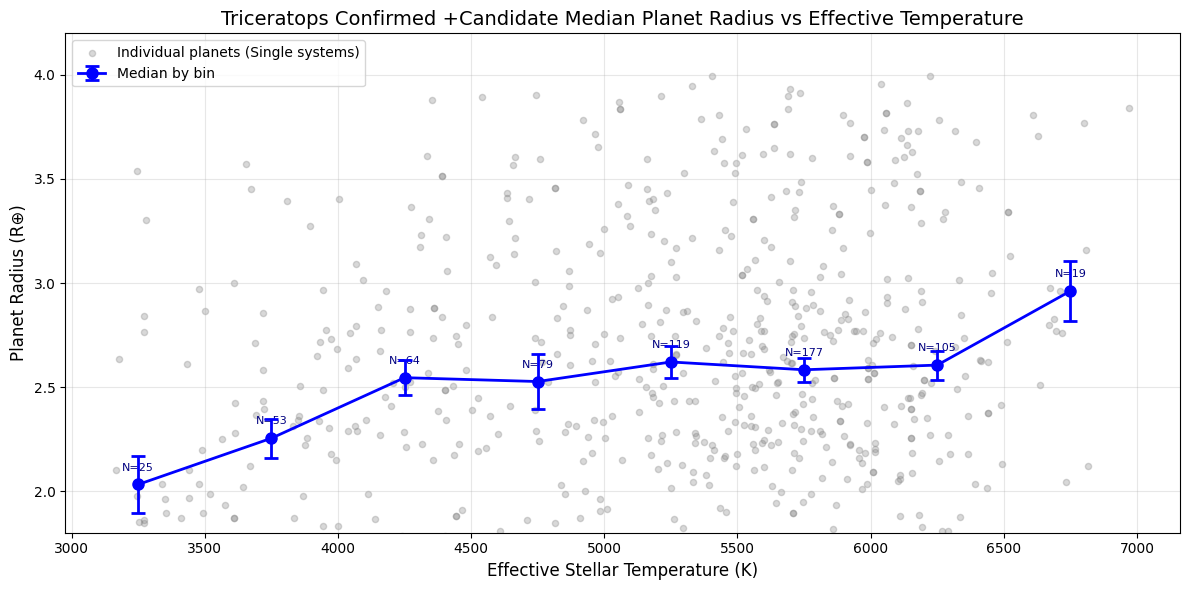

In [11]:

import matplotlib.pyplot as plt
import numpy as np
teff_col = 'st_teff' if 'st_teff' in TOIs.columns else ('Teff' if 'Teff' in TOIs.columns else None)
rad_col = 'st_rad' if 'st_rad' in TOIs.columns else ('Rad' if 'Rad' in TOIs.columns else None)
# Create temperature bins from 3000 to 7000K in 500K intervals
bins = np.arange(3000, 7001, 500)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# Bin the data by stellar effective temperature
TOIs['Teff_bin'] = pd.cut(TOIs[teff_col], bins=bins, labels=bin_labels)

merged_all_cut = TOIs[(TOIs['pl_rade'] <= 4) & (TOIs['pl_rade'] >= 1.8)]
merged_all_cut = TOIs[(TOIs['pl_orbper'] < 25.1) & (TOIs['pl_orbper'] > 0.6028)]
print(f"After radius and period cuts: {len(merged_all_cut)} planets")
print(len(merged_all_cut))
merged_all_cut = TOIs[(TOIs['classification'] == 'Confirmed') | (TOIs['classification'] == 'Candidate')]
print(f"After classification cut: {len(merged_all_cut)} planets")
print(len(merged_all_cut))

# Calculate bin centers for plotting the median values
bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
median_rad_by_teff = merged_all_cut.groupby('Teff_bin')['pl_rade'].median()

# Bootstrap error bars
n_bootstrap = 1000
bootstrap_medians = {bin_label: [] for bin_label in bin_labels}

for _ in range(n_bootstrap):
    # Resample with replacement
    resampled = merged_all_cut.sample(n=len(merged_all_cut), replace=True)
    # Calculate median for each bin
    bin_medians = resampled.groupby('Teff_bin')['pl_rade'].median()
    for bin_label in bin_medians.index:
        bootstrap_medians[bin_label].append(bin_medians[bin_label])

# Calculate standard errors from bootstrap distributions
std_errors_dict = {}
for bin_label in median_rad_by_teff.index:
    if bin_label in bootstrap_medians and len(bootstrap_medians[bin_label]) > 0:
        std_errors_dict[bin_label] = np.std(bootstrap_medians[bin_label])
        print(f"{bin_label}: {len(bootstrap_medians[bin_label])} bootstrap samples, std = {std_errors_dict[bin_label]:.4f}")
    else:
        std_errors_dict[bin_label] = 0
        print(f"{bin_label}: No bootstrap samples!")

# Create aligned arrays for plotting
valid_bin_centers = [bin_centers[i] for i, label in enumerate(bin_labels) if label in median_rad_by_teff.index]
valid_std_errors = [std_errors_dict[label] for label in median_rad_by_teff.index]

fig, (ax_main) = plt.subplots(1, 1, figsize=(12, 6))

# Main scatter plot
ax_main.scatter(merged_all_cut[teff_col], merged_all_cut['pl_rade'], alpha=0.3, s=20, c='gray', label='Individual planets (Single systems)')
ax_main.errorbar(valid_bin_centers, median_rad_by_teff.values, yerr=valid_std_errors, 
                 marker='o', linewidth=2, markersize=8, color='blue', 
                 label='Median by bin', zorder=5, capsize=5, capthick=2)
ax_main.set_xlabel('Effective Stellar Temperature (K)', fontsize=12)
ax_main.set_ylabel('Planet Radius (R⊕)', fontsize=12)
ax_main.set_title('Triceratops Confirmed +Candidate Median Planet Radius vs Effective Temperature', fontsize=14)
ax_main.legend()
ax_main.grid(True, alpha=0.3)
ax_main.set_ylim(1.8, 4.2)

# Print statistics
print("\nMedian Radius by Temperature Bin:")
print(median_rad_by_teff)
print(f'Planets per bin:')
print(merged_all_cut['Teff_bin'].value_counts().sort_index())
print('total planets')
# Add per-bin sample size labels
for x, bin_label in zip(valid_bin_centers, median_rad_by_teff.index):
    n_in_bin = int((merged_all_cut["Teff_bin"] == bin_label).sum())
    y = median_rad_by_teff.loc[bin_label]
    if np.isfinite(y):
        ax_main.annotate(
            f"N={n_in_bin}",
            (x, y),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="navy",
        )

plt.tight_layout()
plt.savefig("triceratops_median_radius_vs_teff.png", dpi=300, bbox_inches="tight")
plt.show()